In [6]:
!pip install -r requirements.txt

In [49]:
import os
import numpy as np
import matplotlib.pyplot as plt

from nltk.tokenize import WordPunctTokenizer
from nltk.translate.bleu_score import corpus_bleu

from sklearn.model_selection import train_test_split
from vocab import Vocab

import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

from IPython.display import clear_output
from tqdm import tqdm, trange

from subword_nmt.learn_bpe import learn_bpe
from subword_nmt.apply_bpe import BPE

%matplotlib inline

In [50]:
random_seed = 42
random.seed(random_seed)
num_epoch = 25000
num_symbols=10000 # увеличим размер словаря с 8000

In [9]:
if not os.path.exists('data.txt'):
    !wget https://www.dropbox.com/s/yy2zqh34dyhv07i/data.txt?dl=1 -O data.txt

--2025-09-17 10:23:43--  https://www.dropbox.com/s/yy2zqh34dyhv07i/data.txt?dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.70.18, 2620:100:6026:18::a27d:4612
Connecting to www.dropbox.com (www.dropbox.com)|162.125.70.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/mw8tdyetqboqwkn5ma886/data.txt?rlkey=t9fmsizx27ikh0vak0ir265a6&dl=1 [following]
--2025-09-17 10:23:44--  https://www.dropbox.com/scl/fi/mw8tdyetqboqwkn5ma886/data.txt?rlkey=t9fmsizx27ikh0vak0ir265a6&dl=1
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc9341bef2601e11f6022f096a9d.dl.dropboxusercontent.com/cd/0/inline/CxihFIObYiS6BHALr375EtHytVaxZUWJQwF6c0wLNB220E-GY_YQP_Jo-QmlLCgKJT0p88w3FOqpCHaE2p_8I6VxfQ4scvGdXMjBSS-ru2eJZKhFZZPt_0B3p-1WN2nDgwY/file?dl=1# [following]
--2025-09-17 10:23:44--  https://uc9341bef2601e11f6022f096a9d.dl.dropboxusercontent.com/cd/0/inline/CxihFIObYiS

In [10]:
with open('data.txt') as f:
  print(f.readlines()[0])

Cordelia Hotel is situated in Tbilisi, a 3-minute walk away from Saint Trinity Church.	Отель Cordelia расположен в Тбилиси, в 3 минутах ходьбы от Свято-Троицкого собора.



In [11]:
tokenizer = WordPunctTokenizer()

def tokenize(x):
  return ' '.join(tokenizer.tokenize(x.lower()))

In [12]:
with open('train.en', 'w') as f_src,  open('train.ru', 'w') as f_dst:
  for line in open('data.txt'):
    src_line, dst_line = line.strip().split('\t')
    f_src.write(tokenize(src_line) + '\n')
    f_dst.write(tokenize(dst_line) + '\n')

In [13]:
bpe = {}
for lang in ['en', 'ru']:
    learn_bpe(open('./train.' + lang), open('bpe_rules.' + lang, 'w'), num_symbols=num_symbols)
    bpe[lang] = BPE(open('./bpe_rules.' + lang))

    with open('train.bpe.' + lang, 'w') as f_out:
        for line in open('train.' + lang):
            f_out.write(bpe[lang].process_line(line.strip()) + '\n')

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:08<00:00, 1170.16it/s]


In [14]:
data_inp = np.array(open('./train.bpe.ru').read().split('\n'))
data_out = np.array(open('./train.bpe.en').read().split('\n'))

train_inp, dev_inp, train_out, dev_out = train_test_split(
    data_inp,
    data_out,
    test_size=3000,
    random_state=2023,
)

for i in range(3):
    print('inp:', train_inp[i])
    print('out:', train_out[i], end='\n\n')

inp: этот отель находится в центре парижа , в 2 минутах от площади республики и станции метро с 5 лини@@ ями метро и 4 автобус@@ ными маршру@@ тами .
out: this hotel is located in the centre of paris , 2 minutes from place de la ré@@ pub@@ li@@ que and its metro station , which offers 5 metro lines and 4 bus lines .

inp: на полностью оборудованной мини - кухне можно самостоятельно готовить .
out: there is a full kitchenette where guests are welcome to prepare their meals .

inp: номера находятся под крышей или на ниж@@ них эта@@ жах с эр@@ ке@@ рами с видом на сад .
out: set under the roof or on the lower floors with bay windows looking out onto the park , they are all equipped with wi - fi access .



In [15]:
inp_voc = Vocab.from_lines(train_inp)
out_voc = Vocab.from_lines(train_out)

In [16]:
batch_lines = sorted(train_inp, key=len)[5:10]
batch_ids = inp_voc.to_matrix(batch_lines)
batch_lines_restored = inp_voc.to_lines(batch_ids)

print("lines")
print(batch_lines)
print("\nwords to ids (0 = bos, 1 = eos):")
print(batch_ids)
print("\nback to words")
print(batch_lines_restored)

lines
['гостевой дом r .', 'имеется балкон .', 'до афин — 20 км .', 'работает боулинг .', 'оборудован балкон .']

words to ids (0 = bos, 1 = eos):
tensor([[   0, 3395, 3695, 1442,   29,    1,    1,    1],
        [   0, 4321, 2399,   29,    1,    1,    1,    1],
        [   0, 3672, 2354, 9914,   63, 4717,   29,    1],
        [   0, 7432, 2653,   29,    1,    1,    1,    1],
        [   0, 6095, 2399,   29,    1,    1,    1,    1]])

back to words
['гостевой дом r .', 'имеется балкон .', 'до афин — 20 км .', 'работает боулинг .', 'оборудован балкон .']


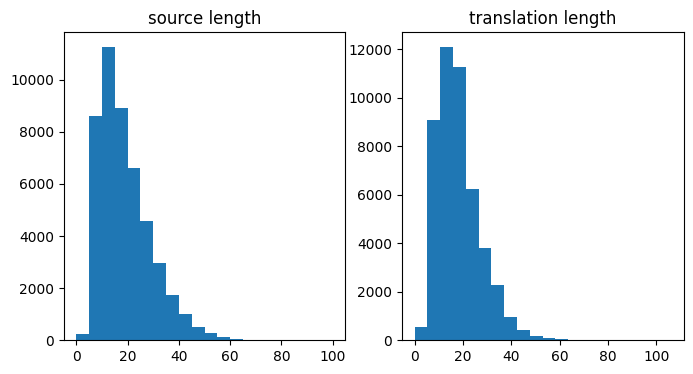

In [17]:
plt.figure(figsize=[8, 4])
plt.subplot(1, 2, 1)
plt.title("source length")
plt.hist(list(map(len, map(str.split, train_inp))), bins=20);

plt.subplot(1, 2, 2)
plt.title("translation length")
plt.hist(list(map(len, map(str.split, train_out))), bins=20);

In [18]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [19]:
class BasicModel(nn.Module):
    def __init__(self, inp_voc, out_voc, emb_size=64, hid_size=128):
        """
        A simple encoder-decoder seq2seq model
        """
        super().__init__()

        self.inp_voc, self.out_voc = inp_voc, out_voc
        self.hid_size = hid_size

        self.emb_inp = nn.Embedding(len(inp_voc), emb_size)
        self.emb_out = nn.Embedding(len(out_voc), emb_size)
        self.enc0 = nn.GRU(emb_size, hid_size, batch_first=True)

        self.dec_start = nn.Linear(hid_size, hid_size)
        self.dec0 = nn.GRUCell(emb_size, hid_size)
        self.logits = nn.Linear(hid_size, len(out_voc))

    def forward(self, inp, out):
        """ Apply model in training mode """
        initial_state = self.encode(inp)
        return self.decode(initial_state, out)


    def encode(self, inp, **flags):
        """
        Takes input sequence, computes initial state
        :param inp: matrix of input tokens [batch, time]
        :returns: initial decoder state tensors, one or many
        """
        inp_emb = self.emb_inp(inp)
        batch_size = inp.shape[0]

        enc_seq, last_state_but_not_really = self.enc0(inp_emb)
        # enc_seq: [batch, sequence length, hid_size], last_state: [batch, hid_size]

        # note: last_state is not _actually_ last because of padding, let's find the real last_state
        lengths = (inp != self.inp_voc.eos_ix).to(torch.int64).sum(dim=1).clamp_max(inp.shape[1] - 1)
        last_state = enc_seq[torch.arange(len(enc_seq)), lengths]
        # ^-- shape: [batch_size, hid_size]

        dec_start = self.dec_start(last_state)
        return [dec_start]

    def decode_step(self, prev_state, prev_tokens, **flags):
        """
        Takes previous decoder state and tokens, returns new state and logits for next tokens
        :param prev_state: a list of previous decoder state tensors, same as returned by encode(...)
        :param prev_tokens: previous output tokens, an int vector of [batch_size]
        :return: a list of next decoder state tensors, a tensor of logits [batch, len(out_voc)]
        """
        prev_gru0_state = prev_state[0]
        prev_emb = self.emb_out(prev_tokens)
        new_dec_state = self.dec0(prev_emb, prev_gru0_state) # input & hidden states
        output_logits = self.logits(new_dec_state)

        return [new_dec_state], output_logits

    def decode(self, initial_state, out_tokens, **flags):
        """ Iterate over reference tokens (out_tokens) with decode_step """
        batch_size = out_tokens.shape[0]
        state = initial_state

        # initial logits: always predict BOS
        onehot_bos = F.one_hot(torch.full([batch_size], self.out_voc.bos_ix, dtype=torch.int64),
                               num_classes=len(self.out_voc)).to(device=out_tokens.device)
        first_logits = torch.log(onehot_bos.to(torch.float32) + 1e-9)

        logits_sequence = [first_logits]
        for i in range(out_tokens.shape[1] - 1):
            state, logits = self.decode_step(state, out_tokens[:, i])
            logits_sequence.append(logits)
        return torch.stack(logits_sequence, dim=1)

    def decode_inference(self, initial_state, max_len=100, **flags):
        """ Generate translations from model (greedy version) """
        batch_size, device = len(initial_state[0]), initial_state[0].device
        state = initial_state
        outputs = [torch.full([batch_size], self.out_voc.bos_ix, dtype=torch.int64,
                              device=device)]
        all_states = [initial_state]

        for i in range(max_len):
            state, logits = self.decode_step(state, outputs[-1])
            outputs.append(logits.argmax(dim=-1))
            all_states.append(state)

        return torch.stack(outputs, dim=1), all_states

    def translate_lines(self, inp_lines, **kwargs):
        inp = self.inp_voc.to_matrix(inp_lines).to(device)
        initial_state = self.encode(inp)
        out_ids, states = self.decode_inference(initial_state, **kwargs)
        return self.out_voc.to_lines(out_ids.cpu().numpy()), states

In [20]:
model = BasicModel(inp_voc, out_voc).to(device)

dummy_inp_tokens = inp_voc.to_matrix(sorted(train_inp, key=len)[5:10]).to(device)
dummy_out_tokens = out_voc.to_matrix(sorted(train_out, key=len)[5:10]).to(device)

h0 = model.encode(dummy_inp_tokens)
h1, logits1 = model.decode_step(h0, torch.arange(len(dummy_inp_tokens), device=device))

assert isinstance(h1, list) and len(h1) == len(h0)
assert h1[0].shape == h0[0].shape and not torch.allclose(h1[0], h0[0])
assert logits1.shape == (len(dummy_inp_tokens), len(out_voc))

logits_seq = model.decode(h0, dummy_out_tokens)
assert logits_seq.shape == (dummy_out_tokens.shape[0], dummy_out_tokens.shape[1], len(out_voc))

# full forward
logits_seq2 = model(dummy_inp_tokens, dummy_out_tokens)
assert logits_seq2.shape == logits_seq.shape

In [21]:
train_inp[:3]

array(['этот отель находится в центре парижа , в 2 минутах от площади республики и станции метро с 5 лини@@ ями метро и 4 автобус@@ ными маршру@@ тами .',
       'на полностью оборудованной мини - кухне можно самостоятельно готовить .',
       'номера находятся под крышей или на ниж@@ них эта@@ жах с эр@@ ке@@ рами с видом на сад .'],
      dtype='<U521')

In [22]:
dummy_translations, dummy_states = model.translate_lines(train_inp[:3], max_len=25)
print("Translations without training:")
print('\n'.join([line for line in dummy_translations]))

Translations without training:
zon thing frequent ün@@ 550 samo@@ baymont fant@@ alo towel@@ tune wines tour metre arev@@ village jel@@ tegel pping ridge unwind occas@@ ys gabri@@ ive
apu@@ gow evi starting st espa@@ ii barajas veli@@ marche sugg@@ tuscany electric arco yoghurt z@@ vi@@ any ox@@ monopoli earth bread acional ento dü@@
supplied gh@@ dé@@ ica quet provided unwind modern ün@@ ün@@ pind@@ em@@ skiy tao clim@@ barajas novella novella fortuna novella novella fortuna sunshine izmir truskav@@


In [23]:
def compute_loss(model, inp, out, **flags):
    """
    Compute loss (float32 scalar) as in the formula above
    :param inp: input tokens matrix, int32[batch, time]
    :param out: reference tokens matrix, int32[batch, time]

    In order to pass the tests, your function should
    * include loss at first EOS but not the subsequent ones
    * divide sum of losses by a sum of input lengths (use voc.compute_mask)
    """
    mask = model.out_voc.compute_mask(out) # [batch_size, out_len]
    targets_1hot = F.one_hot(out, len(model.out_voc)).to(torch.float32)

    # outputs of the model, [batch_size, out_len, num_tokens]
    logits_seq = model(inp, out)

    # log-probabilities of all tokens at all steps, [batch_size, out_len, num_tokens]
    logprobs_seq = torch.log_softmax(logits_seq, dim=-1)

    # log-probabilities of correct outputs, [batch_size, out_len]
    logp_out = (logprobs_seq * targets_1hot).sum(dim=-1)
    # ^-- this will select the probability of the actual next token.
    # Note: you can compute loss more efficiently using using F.cross_entropy

    # average cross-entropy over tokens where mask == True
    return -logp_out[mask].mean()

In [24]:
dummy_loss = compute_loss(model, dummy_inp_tokens, dummy_out_tokens)
print("Loss:", dummy_loss)
assert np.allclose(dummy_loss.item(), 7.5, rtol=0.1, atol=0.1), "We're sorry for your loss"

# test autograd
dummy_loss.backward()
for name, param in model.named_parameters():
    assert param.grad is not None and abs(param.grad.max()) != 0, f"Param {name} received no gradients"

Loss: tensor(7.7505, grad_fn=<NegBackward0>)


In [25]:
def compute_bleu(model, inp_lines, out_lines, bpe_sep='@@ ', **flags):
    """
    Estimates corpora-level BLEU score of model's translations given inp and reference out
    """
    with torch.no_grad():
        translations, _ = model.translate_lines(inp_lines, **flags)
        translations = [line.replace(bpe_sep, '') for line in translations]
        actual = [line.replace(bpe_sep, '') for line in out_lines]
        return corpus_bleu(
            [[ref.split()] for ref in actual],
            [trans.split() for trans in translations],
            smoothing_function=lambda precisions, **kw: [p + 1.0 / p.denominator for p in precisions]
        ) * 100

In [26]:
compute_bleu(model, dev_inp, dev_out)

0.0019397649686436077

In [27]:
metrics = {'train_loss': [], 'dev_bleu': [] }

model = BasicModel(inp_voc, out_voc).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
batch_size = 32

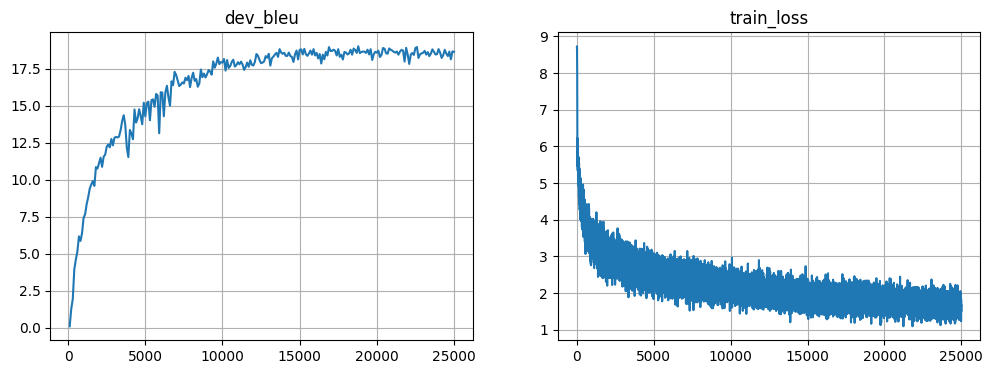

Mean loss=1.609


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25000/25000 [1:57:57<00:00,  3.53it/s]


In [28]:
for _ in trange(25000):
    step = len(metrics['train_loss']) + 1
    batch_ix = np.random.randint(len(train_inp), size=batch_size)
    batch_inp = inp_voc.to_matrix(train_inp[batch_ix]).to(device)
    batch_out = out_voc.to_matrix(train_out[batch_ix]).to(device)

    opt.zero_grad()
    loss_t = compute_loss(model, batch_inp, batch_out)
    loss_t.backward()
    opt.step()

    metrics['train_loss'].append((step, loss_t.item()))

    if step % 100 == 0:
        metrics['dev_bleu'].append((step, compute_bleu(model, dev_inp, dev_out)))

        clear_output(True)
        plt.figure(figsize=(12,4))
        for i, (name, history) in enumerate(sorted(metrics.items())):
            plt.subplot(1, len(metrics), i + 1)
            plt.title(name)
            plt.plot(*zip(*history))
            plt.grid()
        plt.show()
        print("Mean loss=%.3f" % np.mean(metrics['train_loss'][-10:], axis=0)[1], flush=True)

In [29]:
assert np.mean(metrics['dev_bleu'][-10:], axis=0)[1] > 15, "We kind of need a higher bleu BLEU from you. Kind of right now."

In [30]:
for inp_line, trans_line in zip(dev_inp[::500], model.translate_lines(dev_inp[::500])[0]):
    print(inp_line)
    print(trans_line)
    print()

в ванной комнате с ванной предоставляется фен .
the bathroom is fitted with a hairdryer and a hairdryer .

на территории можно сыграть в дартс и сквош .
you can play tennis and squash at the property .

апартаменты располагают гостиной зоной .
the apartment will provide you with a seating area .

гости могут самостоятельно приготовить блюда на полностью укомплектованной кухне .
guests can prepare their own meals in the fully equipped kitchen .

к услугам гостей 2 спальни и 1 ванная комната с ванной и / или душем , а также кухня с духовкой и микроволновой печью .
there is a full kitchen with a microwave and a toaster . a tv with a microwave and a toaster are also provided .

ужин для гостей приготовят в ресторане ron@@ ni@@ e ' s w@@ ing@@ s & o@@ y@@ ster bar .
the restaurant on site restaurant serves gourmet dishes , gourmet american breakfast , which is open .



In [31]:
compute_bleu(model, dev_inp, dev_out)

18.630770390194105

In [32]:
class AttentionLayer(nn.Module):
    def __init__(self, enc_size, dec_size, hid_size):
        """ A layer that computes additive attention response and weights """
        super().__init__()
        self.enc_size = enc_size # num units in encoder state
        self.dec_size = dec_size # num units in decoder state
        self.hid_size = hid_size # attention layer hidden units

        self.linear_enc = nn.Linear(enc_size, hid_size)
        self.linear_dec = nn.Linear(dec_size, hid_size)
        self.linear_out = nn.Linear(hid_size, 1)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, enc, dec, inp_mask):
        """
        Computes attention response and weights
        :param enc: encoder activation sequence, float32[batch_size, ninp, enc_size]
        :param dec: single decoder state used as "query", float32[batch_size, dec_size]
        :param inp_mask: mask on enc activatons (0 after first eos), float32 [batch_size, ninp]
        :returns: attn[batch_size, enc_size], probs[batch_size, ninp]
            - attn - attention response vector (weighted sum of enc)
            - probs - attention weights after softmax
        """
        batch_size, ninp, enc_size = enc.shape

        # Compute logits
        x = self.linear_dec(dec).reshape(-1, 1, self.hid_size)
        x = torch.tanh(self.linear_enc(enc) + x)
        x = self.linear_out(x)

        # Apply mask - if mask is 0, logits should be -inf or -1e9
        # You may need torch.where
        x[torch.where(inp_mask == False)] = -1e9

        # Compute attention probabilities (softmax)
        probs = self.softmax(x.reshape(batch_size, ninp))

        # Compute attention response using enc and probs
        attn = (probs.reshape(batch_size, ninp, 1) * enc).sum(1)

        return attn, probs

In [33]:
class AttentiveModel(BasicModel):
    def __init__(self, inp_voc, out_voc, emb_size=64, hid_size=128, attn_size=128):
        """ Translation model that uses attention. See instructions above. """
        super().__init__(inp_voc, out_voc, emb_size, hid_size)
        self.inp_voc, self.out_voc = inp_voc, out_voc
        self.hid_size = hid_size

        self.enc0 = nn.LSTM(emb_size, hid_size, num_layers=2, batch_first=True)
        self.dec_start = nn.Linear(hid_size, hid_size)

        self.dec0 = nn.GRUCell(emb_size + hid_size, hid_size)
        self.attention = AttentionLayer(hid_size, hid_size, attn_size)


    def encode(self, inp, **flags):
        """
        Takes input sequences, computes initial state
        :param inp: matrix of input tokens [batch, time]
        :return: a list of initial decoder state tensors
        """
        # encode input sequence, create initial decoder states
        inp_emb = self.emb_inp(inp)
        enc_seq, last_state_but_not_really = self.enc0(inp_emb)
        #[dec_start] = super().encode(inp, **flags)

        lengths = (inp != self.inp_voc.eos_ix).to(torch.int64).sum(dim=1).clamp_max(inp.shape[1] - 1)
        last_state = enc_seq[torch.arange(len(enc_seq)), lengths]
        # ^-- shape: [batch_size, hid_size]
        dec_start = self.dec_start(last_state)

        # apply attention layer from initial decoder hidden state
        inp_mask = self.inp_voc.compute_mask(inp)
        first_attn_probas = self.attention(enc_seq, dec_start, inp_mask)

        # Build first state: include
        # * initial states for decoder recurrent layers
        # * encoder sequence and encoder attn mask (for attention)
        # * make sure that last state item is attention probabilities tensor

        first_state = [dec_start, enc_seq, inp_mask, first_attn_probas]
        return first_state

    def decode_step(self, prev_state, prev_tokens, **flags):
        """
        Takes previous decoder state and tokens, returns new state and logits for next tokens
        :param prev_state: a list of previous decoder state tensors
        :param prev_tokens: previous output tokens, an int vector of [batch_size]
        :return: a list of next decoder state tensors, a tensor of logits [batch, n_tokens]
        """

        prev_gru0_state, enc_seq, enc_mask, _ = prev_state
        attn, attn_probs = self.attention(enc_seq, prev_gru0_state, enc_mask)

        x = self.emb_out(prev_tokens)
        x = torch.cat([attn, x], dim=-1)
        x = self.dec0(x, prev_gru0_state)

        new_dec_state = [x, enc_seq, enc_mask, attn_probs]
        output_logits = self.logits(x)
        return [new_dec_state, output_logits]

In [34]:
metrics = {'train_loss': [], 'dev_bleu': [] }

model = AttentiveModel(inp_voc, out_voc).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
batch_size = 32

In [35]:
model

AttentiveModel(
  (emb_inp): Embedding(9927, 64)
  (emb_out): Embedding(9538, 64)
  (enc0): LSTM(64, 128, num_layers=2, batch_first=True)
  (dec_start): Linear(in_features=128, out_features=128, bias=True)
  (dec0): GRUCell(192, 128)
  (logits): Linear(in_features=128, out_features=9538, bias=True)
  (attention): AttentionLayer(
    (linear_enc): Linear(in_features=128, out_features=128, bias=True)
    (linear_dec): Linear(in_features=128, out_features=128, bias=True)
    (linear_out): Linear(in_features=128, out_features=1, bias=True)
    (softmax): Softmax(dim=-1)
  )
)

In [36]:
compute_bleu(model, dev_inp, dev_out)

0.0018462053160146318

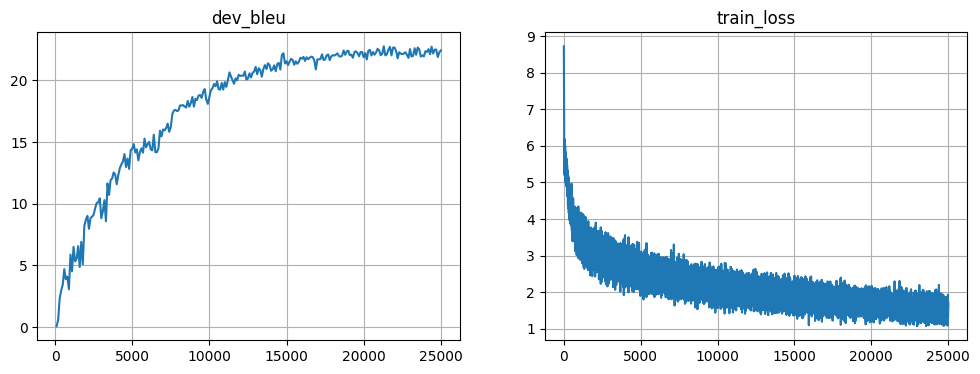

Mean loss=1.514


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25000/25000 [4:35:17<00:00,  1.51it/s]


In [37]:
for _ in trange(25000):
    step = len(metrics['train_loss']) + 1
    batch_ix = np.random.randint(len(train_inp), size=batch_size)
    batch_inp = inp_voc.to_matrix(train_inp[batch_ix]).to(device)
    batch_out = out_voc.to_matrix(train_out[batch_ix]).to(device)

    opt.zero_grad()
    loss_t = compute_loss(model, batch_inp, batch_out)
    loss_t.backward()
    opt.step()

    metrics['train_loss'].append((step, loss_t.item()))

    if step % 100 == 0:
        metrics['dev_bleu'].append((step, compute_bleu(model, dev_inp, dev_out)))

        clear_output(True)
        plt.figure(figsize=(12,4))
        for i, (name, history) in enumerate(sorted(metrics.items())):
            plt.subplot(1, len(metrics), i + 1)
            plt.title(name)
            plt.plot(*zip(*history))
            plt.grid()
        plt.show()
        print("Mean loss=%.3f" % np.mean(metrics['train_loss'][-10:], axis=0)[1], flush=True)

In [38]:
compute_bleu(model, dev_inp, dev_out)

22.442096707512853

In [39]:
for inp_line, trans_line in zip(dev_inp[::500], model.translate_lines(dev_inp[::500])[0]):
    print(inp_line)
    print(trans_line)
    print()

в ванной комнате с ванной предоставляется фен .
the bathroom comes with a bath and a hairdryer .

на территории можно сыграть в дартс и сквош .
you can play car and darts at the hotel .

апартаменты располагают гостиной зоной .
the apartment features a living room .

гости могут самостоятельно приготовить блюда на полностью укомплектованной кухне .
guests can prepare their meals in the fully - equipped kitchen .

к услугам гостей 2 спальни и 1 ванная комната с ванной и / или душем , а также кухня с духовкой и микроволновой печью .
there is a fully - equipped kitchen and a bathroom with a bath or shower and bidet . a kitchen is equipped with a dishwasher and a microwave .

ужин для гостей приготовят в ресторане ron@@ ni@@ e ' s w@@ ing@@ s & o@@ y@@ ster bar .
guests can enjoy the on - site restaurant at the nearby bar , which also guests will be able to enjoy the on - site restaurant .



## Эксперименты

Добавил ядерное сэмплироание, т.к. оно должно помочь убрать бессмысленные токены, сохранив при этом разнообразие генерации.

In [43]:
class NucleusSamplingModel(nn.Module):
    def __init__(self, inp_voc, out_voc, emb_size=64, hid_size=128):
        """
        A simple encoder-decoder seq2seq model
        """
        super().__init__()

        self.inp_voc, self.out_voc = inp_voc, out_voc
        self.hid_size = hid_size

        self.emb_inp = nn.Embedding(len(inp_voc), emb_size)
        self.emb_out = nn.Embedding(len(out_voc), emb_size)
        self.enc0 = nn.GRU(emb_size, hid_size, batch_first=True)

        self.dec_start = nn.Linear(hid_size, hid_size)
        self.dec0 = nn.GRUCell(emb_size, hid_size)
        self.logits = nn.Linear(hid_size, len(out_voc))

    def forward(self, inp, out):
        """ Apply model in training mode """
        initial_state = self.encode(inp)
        return self.decode(initial_state, out)


    def encode(self, inp, **flags):
        """
        Takes input sequence, computes initial state
        :param inp: matrix of input tokens [batch, time]
        :returns: initial decoder state tensors, one or many
        """
        inp_emb = self.emb_inp(inp)
        batch_size = inp.shape[0]

        enc_seq, last_state_but_not_really = self.enc0(inp_emb)
        # enc_seq: [batch, sequence length, hid_size], last_state: [batch, hid_size]

        # note: last_state is not _actually_ last because of padding, let's find the real last_state
        lengths = (inp != self.inp_voc.eos_ix).to(torch.int64).sum(dim=1).clamp_max(inp.shape[1] - 1)
        last_state = enc_seq[torch.arange(len(enc_seq)), lengths]
        # ^-- shape: [batch_size, hid_size]

        dec_start = self.dec_start(last_state)
        return [dec_start]

    def decode_step(self, prev_state, prev_tokens, **flags):
        """
        Takes previous decoder state and tokens, returns new state and logits for next tokens
        :param prev_state: a list of previous decoder state tensors, same as returned by encode(...)
        :param prev_tokens: previous output tokens, an int vector of [batch_size]
        :return: a list of next decoder state tensors, a tensor of logits [batch, len(out_voc)]
        """
        prev_gru0_state = prev_state[0]
        prev_emb = self.emb_out(prev_tokens)
        new_dec_state = self.dec0(prev_emb, prev_gru0_state) # input & hidden states
        output_logits = self.logits(new_dec_state)

        return [new_dec_state], output_logits

    def decode(self, initial_state, out_tokens, **flags):
        """ Iterate over reference tokens (out_tokens) with decode_step """
        batch_size = out_tokens.shape[0]
        state = initial_state

        # initial logits: always predict BOS
        onehot_bos = F.one_hot(torch.full([batch_size], self.out_voc.bos_ix, dtype=torch.int64),
                               num_classes=len(self.out_voc)).to(device=out_tokens.device)
        first_logits = torch.log(onehot_bos.to(torch.float32) + 1e-9)

        logits_sequence = [first_logits]
        for i in range(out_tokens.shape[1] - 1):
            state, logits = self.decode_step(state, out_tokens[:, i])
            logits_sequence.append(logits)
        return torch.stack(logits_sequence, dim=1)

    def decode_inference(self, initial_state, max_len=100, temperature=1.0, top_p=0.9, **flags):
        """ Generate translations from model with nucleus sampling """
        batch_size, device = len(initial_state[0]), initial_state[0].device
        state = initial_state
        outputs = [torch.full([batch_size], self.out_voc.bos_ix, dtype=torch.int64,
                              device=device)]
        all_states = [initial_state]
    
        for i in range(max_len):
            state, logits = self.decode_step(state, outputs[-1])
            logits = logits / temperature
            
            # Apply softmax to get probabilities
            probs = torch.softmax(logits, dim=-1)
            sorted_probs, sorted_indices = torch.sort(probs, descending=True, dim=-1)
            cumulative_probs = torch.cumsum(sorted_probs, dim=-1)
            # Remove tokens with cumulative probability above the threshold
            remove_mask = cumulative_probs > top_p
            
            remove_mask[:, 1:] = remove_mask[:, :-1].clone()
            remove_mask[:, 0] = False # Чтобы остался хотя бы 1 токен
            
            # Scatter back to original indices and remove low-probability tokens
            remove_mask = remove_mask.scatter(1, sorted_indices, remove_mask)
            probs[remove_mask] = 0
            
            # Renormalize and sample
            probs = probs / probs.sum(dim=-1, keepdim=True)
            next_token = torch.multinomial(probs, 1).squeeze(-1)
            
            outputs.append(next_token)
            all_states.append(state)
    
        return torch.stack(outputs, dim=1), all_states

    def translate_lines(self, inp_lines, temperature=1.0, top_p=0.9, **kwargs):
        inp = self.inp_voc.to_matrix(inp_lines).to(device)
        initial_state = self.encode(inp)
        out_ids, states = self.decode_inference(initial_state, temperature=temperature, top_p=top_p, **kwargs)
        return self.out_voc.to_lines(out_ids.cpu().numpy()), states

#### Замена GRU LSTM

LSTM должна лучше работать с текстом за счёт того, что она меньше забывает его части. Возможно, что на коротких текстах выигрыш от LSTM не будет заметен. Также используется ядерное сэмплирование, которое должно повысить разнообразие генерации по сравнению с выбором наиболее вероятного токена.

In [44]:
class AttentiveModelBothLSTM(NucleusSamplingModel):
    def __init__(self, inp_voc, out_voc, emb_size=64, hid_size=128, attn_size=128):
        """ Translation model that uses attention. See instructions above. """
        super().__init__(inp_voc, out_voc, emb_size, hid_size)
        self.inp_voc, self.out_voc = inp_voc, out_voc
        self.hid_size = hid_size

        self.enc0 = nn.LSTM(emb_size, hid_size, num_layers=2, batch_first=True)
        self.dec_start = nn.Linear(hid_size, hid_size)

        self.dec0 = nn.LSTM(emb_size + hid_size, hid_size)
        self.attention = AttentionLayer(hid_size, hid_size, attn_size)


    def encode(self, inp, **flags):
        """
        Takes input sequences, computes initial state
        :param inp: matrix of input tokens [batch, time]
        :return: a list of initial decoder state tensors
        """
        # encode input sequence, create initial decoder states
        inp_emb = self.emb_inp(inp)
        enc_seq, last_state_but_not_really = self.enc0(inp_emb)
        #[dec_start] = super().encode(inp, **flags)

        lengths = (inp != self.inp_voc.eos_ix).to(torch.int64).sum(dim=1).clamp_max(inp.shape[1] - 1)
        last_state = enc_seq[torch.arange(len(enc_seq)), lengths]
        # ^-- shape: [batch_size, hid_size]
        dec_start = self.dec_start(last_state)

        # apply attention layer from initial decoder hidden state
        inp_mask = self.inp_voc.compute_mask(inp)
        first_attn_probas = self.attention(enc_seq, dec_start, inp_mask)

        # Build first state: include
        # * initial states for decoder recurrent layers
        # * encoder sequence and encoder attn mask (for attention)
        # * make sure that last state item is attention probabilities tensor

        first_state = [dec_start, enc_seq, inp_mask, first_attn_probas]
        return first_state

    def decode_step(self, prev_state, prev_tokens, **flags):
        """
        Takes previous decoder state and tokens, returns new state and logits for next tokens
        :param prev_state: a list of previous decoder state tensors
        :param prev_tokens: previous output tokens, an int vector of [batch_size]
        :return: a list of next decoder state tensors, a tensor of logits [batch, n_tokens]
        """

        prev_gru0_state, enc_seq, enc_mask, _ = prev_state
        attn, attn_probs = self.attention(enc_seq, prev_gru0_state, enc_mask)

        x = self.emb_out(prev_tokens)
        x = torch.cat([attn, x], dim=-1)
        x = self.dec0(x, prev_gru0_state)

        new_dec_state = [x, enc_seq, enc_mask, attn_probs]
        output_logits = self.logits(x)
        return [new_dec_state, output_logits]

#### Двунаправленная с GRU

In [45]:
class AttentiveModel_Bidirectional_GRU(nn.Module):
    def __init__(self, inp_voc, out_voc, emb_size=64, hid_size=128, attn_size=128):
        """ Translation model with bidirectional GRU encoder and GRUCell decoder """
        super().__init__()
        self.inp_voc, self.out_voc = inp_voc, out_voc
        self.hid_size = hid_size

        # Embeddings
        self.emb_inp = nn.Embedding(len(inp_voc), emb_size, padding_idx=inp_voc.pad_ix)
        self.emb_out = nn.Embedding(len(out_voc), emb_size, padding_idx=out_voc.pad_ix)

        # Encoder: Bidirectional GRU (2 layers)
        self.enc0 = nn.GRU(
            emb_size, hid_size,
            num_layers=2,
            batch_first=True,
            bidirectional=True
        )
        self.dec_start = nn.Linear(2 * hid_size, hid_size)
        
        self.dec0 = nn.GRUCell(emb_size + hid_size, hid_size)
        self.attention = AttentionLayer(2 * hid_size, hid_size, attn_size)

        self.logits = nn.Linear(hid_size, len(out_voc))

    def encode(self, inp, **flags):
        """
        Takes input sequences, computes initial state
        :param inp: matrix of input tokens [batch, time]
        :return: a list of initial decoder state tensors
        """
        # Embed input
        inp_emb = self.emb_inp(inp)  # [B, T, emb_size]
        enc_seq, h_n = self.enc0(inp_emb)  # enc_seq: [B, T, 2*hid_size], h_n: [4, B, hid_size]

        # Extract last layer's hidden states (forward + backward)
        # h_n shape: [num_layers * 2, batch, hid_size]
        # We want the last layer (index -1) for both directions
        last_layer_forward = h_n[-2]  # last layer, forward direction
        last_layer_backward = h_n[-1] # last layer, backward direction
        last_state = torch.cat([last_layer_forward, last_layer_backward], dim=-1)  # [B, 2*hid_size]

        # Project to decoder hidden size
        dec_start = self.dec_start(last_state)  # [B, hid_size]

        # Create mask for input (ignore padding and EOS)
        # Note: we use inp_voc.pad_ix to compute mask
        inp_mask = (inp != self.inp_voc.pad_ix).bool()  # [B, T]

        # Compute first attention using initial decoder state
        first_attn, first_attn_probs = self.attention(enc_seq, dec_start, inp_mask)

        # Return initial state: [dec_hidden, enc_seq, inp_mask, attn_probs]
        first_state = [dec_start, enc_seq, inp_mask, first_attn_probs]
        return first_state

    def decode_step(self, prev_state, prev_tokens, **flags):
        """
        Takes previous decoder state and tokens, returns new state and logits for next tokens
        :param prev_state: [dec_hidden, enc_seq, enc_mask, attn_probs]
        :param prev_tokens: previous output tokens, an int vector of [batch_size]
        :return: [new_dec_state, output_logits]
        """
        prev_hidden, enc_seq, enc_mask, _ = prev_state
        attn, attn_probs = self.attention(enc_seq, prev_hidden, enc_mask)

        # Get embedding of previous token
        x = self.emb_out(prev_tokens)  # [B, emb_size]
        x = torch.cat([attn, x], dim=-1)  # [B, emb_size + hid_size]
        new_hidden = self.dec0(x, prev_hidden)  # [B, hid_size]
        new_dec_state = [new_hidden, enc_seq, enc_mask, attn_probs]

        output_logits = self.logits(new_hidden)  # [B, vocab_size]

        return [new_dec_state, output_logits]

    def decode_inference(self, initial_state, max_len=100, **flags):
        """ Generate translations from model (greedy version) """
        initial_hidden, enc_seq, enc_mask, _ = initial_state
        batch_size = initial_hidden.shape[0]
        device = initial_hidden.device

        # Start with BOS token
        outputs = [torch.full([batch_size], self.out_voc.bos_ix, dtype=torch.int64, device=device)]
        all_states = [initial_state]

        for i in range(max_len):
            state, logits = self.decode_step(all_states[-1], outputs[-1])
            next_token = logits.argmax(dim=-1)  # Greedy decoding
            outputs.append(next_token)
            all_states.append(state)

            # Optional: early stop if all generated EOS
            if (next_token == self.out_voc.eos_ix).all():
                break

        return torch.stack(outputs, dim=1), all_states

### Обучение с ранней остановкой lr schedualing и Adam

In [55]:
def upgraded_training(model, metrics):
    opt_adam = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    scheduler = ReduceLROnPlateau(opt_adam, mode='max', factor=0.5, patience=5, min_lr=1e-6)
    best_bleu = 0.0
    patience_counter = 0
    patience = 10
    
    for _ in trange(num_epoch):
        step = len(metrics['train_loss']) + 1
        batch_ix = np.random.randint(len(train_inp), size=batch_size)
        batch_inp = inp_voc.to_matrix(train_inp[batch_ix]).to(device)
        batch_out = out_voc.to_matrix(train_out[batch_ix]).to(device)
    
        opt_adam.zero_grad()
        loss_t = compute_loss(model, batch_inp, batch_out)
        loss_t.backward()
        opt_adam.step()
    
        metrics['train_loss'].append((step, loss_t.item()))
    
        if step % 100 == 0:
            current_bleu = compute_bleu(model, dev_inp, dev_out)
            metrics['dev_bleu'].append((step, current_bleu))
            scheduler.step(current_bleu)
            
            if current_bleu > best_bleu:
                best_bleu = current_bleu
                patience_counter = 0
                torch.save(model.state_dict(), 'best_model.pth')
            else:
                patience_counter += 1
                
            if patience_counter >= patience:
                print(f"Early stopping triggered after {step} steps")
                model.load_state_dict(torch.load('best_model.pth'))
                break
    
            clear_output(True)
            plt.figure(figsize=(12,4))
            for i, (name, history) in enumerate(sorted(metrics.items())):
                plt.subplot(1, len(metrics), i + 1)
                plt.title(name)
                plt.plot(*zip(*history))
                plt.grid()
            plt.show()
            
            current_lr = opt_adam.param_groups[0]['lr']
            print(f"Mean loss={np.mean(metrics['train_loss'][-10:], axis=0)[1]:.3f}, "
                  f"BLEU={current_bleu:.3f}, LR={current_lr:.2e}, "
                  f"Patience={patience_counter}/{patience}", flush=True)
    
    model.load_state_dict(torch.load('best_model.pth'))
    print(f"Training completed. Best BLEU: {best_bleu:.3f}")

## LSTM-LSTM с ядерным сэмплированием

In [53]:
metrics_AttentiveModelBothLSTM = {'train_loss': [], 'dev_bleu': [] }
model_AttentiveModelBothLSTM = AttentiveModel(inp_voc, out_voc).to(device)

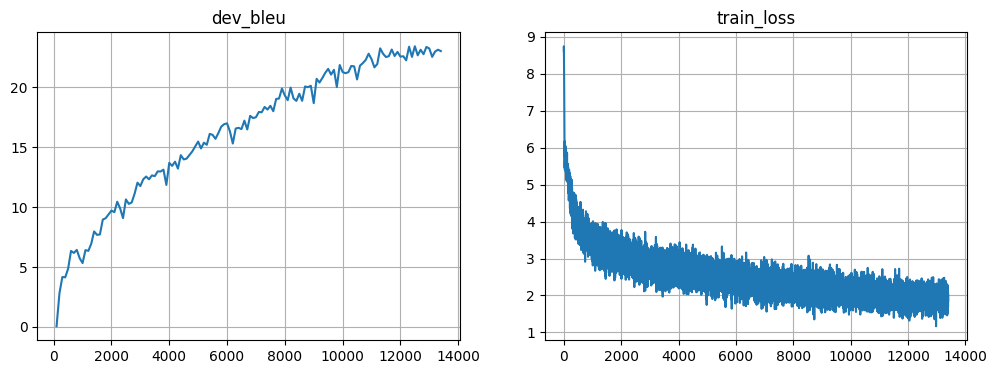

Mean loss=1.922, BLEU=23.009, LR=1.25e-04, Patience=9/10


 54%|████████████████████████████████████████████████████████████████▊                                                        | 13399/25000 [2:26:43<2:07:02,  1.52it/s]

Early stopping triggered after 13500 steps
Training completed. Best BLEU: 23.409


In [56]:
upgraded_training(model_AttentiveModelBothLSTM, metrics_AttentiveModelBothLSTM)

In [63]:
for inp_line, trans_line in zip(dev_inp[::500], model_AttentiveModelBothLSTM.translate_lines(dev_inp[::500])[0]):
    print(inp_line)
    print(trans_line)
    print()

в ванной комнате с ванной предоставляется фен .
the bathroom comes with a bath and a hairdryer .

на территории можно сыграть в дартс и сквош .
you can play tennis and darts .

апартаменты располагают гостиной зоной .
the accommodation will provide you with a seating area .

гости могут самостоятельно приготовить блюда на полностью укомплектованной кухне .
guests can prepare their own meals in the fully equipped kitchen .

к услугам гостей 2 спальни и 1 ванная комната с ванной и / или душем , а также кухня с духовкой и микроволновой печью .
the 2 - bedroom house features a bathroom with a bath and a bath and a shower .

ужин для гостей приготовят в ресторане ron@@ ni@@ e ' s w@@ ing@@ s & o@@ y@@ ster bar .
the restaurant at hotel la maison & restaurant serves a daily breakfast .



## Двунаправленная GRU

In [65]:
metrics_AttentiveModel_Bidirectional_GRU = {'train_loss': [], 'dev_bleu': [] }
model_AttentiveModel_Bidirectional_GRU = AttentiveModel(inp_voc, out_voc).to(device)

In [66]:
for inp_line, trans_line in zip(dev_inp[::500], model_AttentiveModel_Bidirectional_GRU.translate_lines(dev_inp[::500])[0]):
    print(inp_line)
    print(trans_line)
    print()

в ванной комнате с ванной предоставляется фен .
tavi@@ ato@@ scrambled daemun nik straße eu@@ 280 re@@ goo@@ goo@@ the gazebos canberra taksim ć year splash minibar mar@@ mar@@ simply dish zz@@ sever@@ dé@@ age ritz hydro tropicana virgins dem@@ eu@@ impres@@ spoilt truck truck pyatigorsk ei factory disney reserved piccadilly wolf@@ see@@ um@@ um@@ this abled home@@ oma@@ retro pub@@ raki mallorca areas af rival petting petting monti sis@@ yong desert zawa ř@@ need jean arly arly laz@@ joaqu@@ slopes nt@@ off buildings đ zu dru@@ py@@ mo tee salto standing period galil@@ arly treatments treatments ceiling ese ese vio@@ waff@@ ail homewood änn@@ kho@@ maria arly

на территории можно сыграть в дартс и сквош .
tavi@@ ato@@ scrambled daemun nik straße eu@@ 280 re@@ goo@@ goo@@ the gazebos canberra taksim ć year splash minibar mar@@ mar@@ simply dish zz@@ sever@@ dé@@ age ritz hydro tropicana virgins dem@@ eu@@ impres@@ spoilt truck truck pyatigorsk ei factory disney reserved piccadilly wol

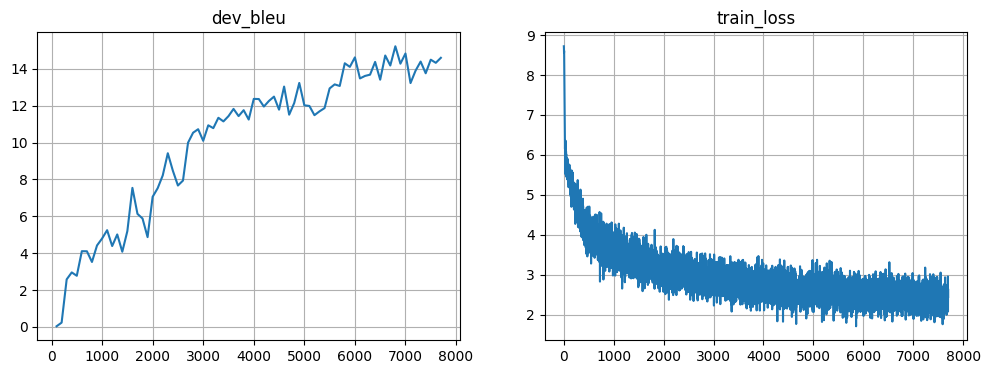

Mean loss=2.418, BLEU=14.598, LR=2.50e-04, Patience=9/10


 31%|█████████████████████████████                                                                | 7799/25000 [1:22:18<3:01:31,  1.58it/s]

Early stopping triggered after 7800 steps
Training completed. Best BLEU: 15.224


In [67]:
upgraded_training(model_AttentiveModel_Bidirectional_GRU, metrics_AttentiveModel_Bidirectional_GRU)

In [68]:
for inp_line, trans_line in zip(dev_inp[::500], model_AttentiveModel_Bidirectional_GRU.translate_lines(dev_inp[::500])[0]):
    print(inp_line)
    print(trans_line)
    print()

в ванной комнате с ванной предоставляется фен .
the bathroom comes with a shower and a hairdryer .

на территории можно сыграть в дартс и сквош .
other facilities offered at the property include a games room and a tour desk .

апартаменты располагают гостиной зоной .
the apartment will provide you with a tv .

гости могут самостоятельно приготовить блюда на полностью укомплектованной кухне .
guests can prepare their meals in the dining area .

к услугам гостей 2 спальни и 1 ванная комната с ванной и / или душем , а также кухня с духовкой и микроволновой печью .
the apartment has a fully equipped kitchen with a dishwasher and a microwave . there is a private bathroom with a bath or shower .

ужин для гостей приготовят в ресторане ron@@ ni@@ e ' s w@@ ing@@ s & o@@ y@@ ster bar .
the restaurant serves a variety of local dishes from the hotel .



## Результаты

Попытка увеличить размер словаря с 8000 до 10000 привела к падению BLEU с 22.966888722528044 до 18.630770390194105. Возможно, причина в том, что для данного блока слов такой словарь избыточный или в словарь попали опечатки. Возможно, также возникла проблема с в вычислением кросс-энтропии из-за большого словаря, из-за чего модель стала хуже обучаться.
Двунаправленная GRU показала худшие результаты 15.224. Возможно, дело в том, что она забывает текст быстрее чем LSTM.
Однонаправленная модель, в которой и энкодер и декодер - LSTM с ядерным сэмплированием показала лучшие результаты на том же словаре - 23.409.